# E-Reputation AI — Training & Experimentation Notebook

This notebook documents the training and experimentation workflow used by the E-Reputation AI project.

**Repository note:** model weights are not committed to GitHub because of their size. Paths have been normalized to repository-relative paths where applicable.

The substantive training and evaluation cells from the original project notebook are preserved.


In [11]:
pip install pandas pyarrow

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install streamlit transformers torch pandas numpy plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
pip install emoji

Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install beautifulsoup4

Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install transformers datasets evaluate scikit-learn accelerate

Note: you may need to restart the kernel to use updated packages.


In [21]:
pip install evaluate rouge_score absl-py nltk

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=25027 sha256=87ebdc25c3e90ee72726ba4721bb9dec6789972df515d79144ca3ba0c11d7aa7
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\5f\dd\89\461065a73be61a532ff8599a28e9beef17985c9e9c31e541b4
Successfully built rouge_score

   ---------------------------------------- 0/2 [absl-py]
   ---------------------------------------- 0/2 [absl-py]
   ---------------------------------------- 2/2 [rouge_score]

Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd
import emoji
import re
from bs4 import BeautifulSoup
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import evaluate

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)


In [16]:
df = pd.read_parquet("../data/raw/booking.parquet")

print(df.shape)
df.head()

(515738, 2)


,Negative_Review,Positive_Review
0,I am so angry that i made this post available...,Only the park outside of the hotel was beauti...
1,No Negative,No real complaints the hotel was great great ...
2,Rooms are nice but for elderly a bit difficul...,Location was good and staff were ok It is cut...
3,My room was dirty and I was afraid to walk ba...,Great location in nice surroundings the bar a...
4,You When I booked with your company on line y...,Amazing location and building Romantic setting


In [17]:
import pandas as pd

# Charger le dataset parquet
df = pd.read_parquet("../data/raw/booking.parquet")

print("Dataset shape:", df.shape)
print("Colonnes:", df.columns)

# Extraire les avis positifs et négatifs
positive_reviews = df["Positive_Review"]
negative_reviews = df["Negative_Review"]

# Supprimer les valeurs vides
positive_reviews = positive_reviews[positive_reviews != "No Positive"]
negative_reviews = negative_reviews[negative_reviews != "No Negative"]

# Prendre 20000 avis de chaque
positive_sample = positive_reviews.sample(20000, random_state=42)
negative_sample = negative_reviews.sample(20000, random_state=42)

# Créer dataset positif
pos_df = pd.DataFrame({
    "Review": positive_sample,
    "Sentiment": "positive"
})

# Créer dataset négatif
neg_df = pd.DataFrame({
    "Review": negative_sample,
    "Sentiment": "negative"
})

# Fusionner les deux datasets
dataset = pd.concat([pos_df, neg_df])

# Mélanger les données
dataset = dataset.sample(frac=1).reset_index(drop=True)

# Sauvegarder le dataset
dataset.to_csv("../data/interim/hotel_reviews_dataset.csv", index=False)

print(dataset["Sentiment"].value_counts())
dataset.head()

Dataset shape: (515738, 2)
Colonnes: Index(['Negative_Review', 'Positive_Review'], dtype='object')
Sentiment
negative    20000
positive    20000
Name: count, dtype: int64


,Review,Sentiment
0,Nothing,negative
1,Staff really helpful,positive
2,Rooms weren t very soundproof and our neighbo...,negative
3,I loved the Skybar and the apple equipment at...,positive
4,There was a weird noise which was hard to sle...,negative


In [18]:
# charger le dataset
df = pd.read_csv("../data/interim/hotel_reviews_dataset.csv")

print("Shape avant suppression :", df.shape)

# supprimer les valeurs manquantes
df = df.dropna(subset=["Review", "Sentiment"])

print("Shape après suppression :", df.shape)

# vérifier s'il reste des valeurs manquantes
print(df.isnull().sum())

df.head()

Shape avant suppression : (40000, 2)
Shape après suppression : (40000, 2)
Review       0
Sentiment    0
dtype: int64


,Review,Sentiment
0,Nothing,negative
1,Staff really helpful,positive
2,Rooms weren t very soundproof and our neighbo...,negative
3,I loved the Skybar and the apple equipment at...,positive
4,There was a weird noise which was hard to sle...,negative


In [19]:
# afficher le nombre de lignes avant suppression
print("Shape avant suppression des doublons :", df.shape)

# supprimer les doublons basés sur la colonne Review
df = df.drop_duplicates(subset=["Review"])

# afficher le nombre de lignes après suppression
print("Shape après suppression des doublons :", df.shape)

# vérifier combien de doublons il reste
print("Nombre de doublons restants :", df.duplicated(subset=["Review"]).sum())

Shape avant suppression des doublons : (40000, 2)
Shape après suppression des doublons : (36211, 2)
Nombre de doublons restants : 0


In [20]:
import emoji

# fonction conversion emojis
def convert_emojis(text):
    if isinstance(text, str):   # vérifier que c'est du texte
        return emoji.demojize(text)
    return text

# appliquer la conversion
df["Review"] = df["Review"].apply(convert_emojis)

# message de confirmation
print("✅ Emojis converted successfully!")

# afficher quelques exemples
df.head()

✅ Emojis converted successfully!


,Review,Sentiment
0,Nothing,negative
1,Staff really helpful,positive
2,Rooms weren t very soundproof and our neighbo...,negative
3,I loved the Skybar and the apple equipment at...,positive
4,There was a weird noise which was hard to sle...,negative


In [21]:
emoticons = {

# smiles / positive
":)": "smile",
":-)": "smile",
":D": "laugh",
":-D": "laugh",
"=)": "smile",
":]": "smile",
":')": "happy",
":')": "happy",
":>": "smile",

# winks
";)": "wink",
";-)": "wink",

# laughing
"XD": "laugh",
"xD": "laugh",

# sad
":(": "sad",
":-(": "sad",
"=(": "sad",
":[": "sad",

# crying
":'(": "cry",
":,-(": "cry",

# angry
">:(": "angry",
">:-(": "angry",

# skeptical
":/": "skeptical",
":-/": "skeptical",
":|": "neutral",

# surprise
":O": "surprised",
":-O": "surprised",
":o": "surprised",

# kiss
":*": "kiss",
":-*": "kiss",

# tongue / sarcasm
":P": "playful",
":-P": "playful",
":p": "playful",
":-p": "playful",

# confused
":S": "confused",
":-S": "confused"

}
def convert_emoticons(text):
    
    if not isinstance(text, str):
        return text
    
    for emoticon, meaning in emoticons.items():
        text = text.replace(emoticon, " " + meaning + " ")
        
    return text


df["Review"] = df["Review"].apply(convert_emoticons)
# message de confirmation
print("✅ Emoticons converted successfully!")

✅ Emoticons converted successfully!


In [22]:
# convertir tout en minuscules
df["Review"] = df["Review"].str.lower()

# message de confirmation
print("✅ Lowercasing applied successfully!")

# aperçu
df.head()

✅ Lowercasing applied successfully!


,Review,Sentiment
0,nothing,negative
1,staff really helpful,positive
2,rooms weren t very soundproof and our neighbo...,negative
3,i loved the skybar and the apple equipment at...,positive
4,there was a weird noise which was hard to sle...,negative


In [23]:
def remove_urls(text):
    if isinstance(text, str):
        return re.sub(r"http\S+|www\S+", "", text)
    return text

df["Review"] = df["Review"].apply(remove_urls)

print("✅ URLs removed successfully!")
df.head()

✅ URLs removed successfully!


,Review,Sentiment
0,nothing,negative
1,staff really helpful,positive
2,rooms weren t very soundproof and our neighbo...,negative
3,i loved the skybar and the apple equipment at...,positive
4,there was a weird noise which was hard to sle...,negative


In [24]:
# fonction pour supprimer les emails
def remove_emails(text):
    if isinstance(text, str):
        return re.sub(r'\S+@\S+', '', text)
    return text

# appliquer sur la colonne Review
df["Review"] = df["Review"].apply(remove_emails)

# message de confirmation
print("✅ Emails removed successfully!")

# aperçu
df.head()

✅ Emails removed successfully!


,Review,Sentiment
0,nothing,negative
1,staff really helpful,positive
2,rooms weren t very soundproof and our neighbo...,negative
3,i loved the skybar and the apple equipment at...,positive
4,there was a weird noise which was hard to sle...,negative


In [25]:
# fonction pour enlever les balises HTML
def remove_html_tags(text):
    
    if isinstance(text, str):
        soup = BeautifulSoup(text, "html.parser")
        return soup.get_text()
    
    return text


# appliquer sur la colonne Review
df["Review"] = df["Review"].apply(remove_html_tags)

# message de confirmation
print("✅ HTML tags removed successfully!")

# aperçu
df.head()

✅ HTML tags removed successfully!


,Review,Sentiment
0,nothing,negative
1,staff really helpful,positive
2,rooms weren t very soundproof and our neighbo...,negative
3,i loved the skybar and the apple equipment at...,positive
4,there was a weird noise which was hard to sle...,negative


In [26]:
# fonction pour nettoyer la ponctuation
def remove_punctuation(text):
    
    if isinstance(text, str):
        # garder ! ? '
        text = re.sub(r"[^\w\s!?']", "", text)
        
    return text


# appliquer sur la colonne Review
df["Review"] = df["Review"].apply(remove_punctuation)

# message de confirmation
print("✅ Punctuation cleaned successfully!")

# aperçu
df.head()

✅ Punctuation cleaned successfully!


,Review,Sentiment
0,nothing,negative
1,staff really helpful,positive
2,rooms weren t very soundproof and our neighbo...,negative
3,i loved the skybar and the apple equipment at...,positive
4,there was a weird noise which was hard to sle...,negative


In [27]:
# fonction pour supprimer les caractères non alphabétiques
def remove_non_alphabetic(text):
    
    if isinstance(text, str):
        # garder lettres, espaces, ! ? '
        text = re.sub(r"[^a-zA-Z\s!?']", "", text)
        
    return text


# appliquer sur la colonne Review
df["Review"] = df["Review"].apply(remove_non_alphabetic)

# message de confirmation
print("✅ Non-alphabetic characters removed successfully!")

# aperçu
df.head()

✅ Non-alphabetic characters removed successfully!


,Review,Sentiment
0,nothing,negative
1,staff really helpful,positive
2,rooms weren t very soundproof and our neighbo...,negative
3,i loved the skybar and the apple equipment at...,positive
4,there was a weird noise which was hard to sle...,negative


In [28]:
# fonction pour supprimer les espaces multiples
def remove_extra_spaces(text):
    
    if isinstance(text, str):
        text = re.sub(r'\s+', ' ', text).strip()
        
    return text


# appliquer sur la colonne Review
df["Review"] = df["Review"].apply(remove_extra_spaces)

# message de confirmation
print("✅ Extra white spaces removed successfully!")

# aperçu
df.head()

✅ Extra white spaces removed successfully!


,Review,Sentiment
0,nothing,negative
1,staff really helpful,positive
2,rooms weren t very soundproof and our neighbou...,negative
3,i loved the skybar and the apple equipment at ...,positive
4,there was a weird noise which was hard to slee...,negative


In [29]:
# afficher taille avant
print("Shape before removing short reviews:", df.shape)

# supprimer les reviews trop courtes
df = df[df["Review"].str.len() > 10]

# afficher taille après
print("Shape after removing short reviews:", df.shape)

df.head()

Shape before removing short reviews: (36211, 2)
Shape after removing short reviews: (35625, 2)


,Review,Sentiment
1,staff really helpful,positive
2,rooms weren t very soundproof and our neighbou...,negative
3,i loved the skybar and the apple equipment at ...,positive
4,there was a weird noise which was hard to slee...,negative
5,as already stated there was nothing that we di...,negative


In [33]:
# vérifier la distribution initiale
print("Before balancing:")
print(df["Sentiment"].value_counts())

# séparer les classes
df_positive = df[df["Sentiment"] == "positive"]
df_negative = df[df["Sentiment"] == "negative"]

# prendre exactement 17500 dans chaque classe
df_positive_balanced = df_positive.sample(17500, random_state=42)
df_negative_balanced = df_negative.sample(17500, random_state=42)

# fusionner
df_balanced = pd.concat([df_positive_balanced, df_negative_balanced])

# mélanger le dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# vérifier
print("\nAfter balancing:")
print(df_balanced["Sentiment"].value_counts())

print("\nFinal dataset shape:", df_balanced.shape)

Before balancing:
Sentiment
positive    18026
negative    17599
Name: count, dtype: int64

After balancing:
Sentiment
negative    17500
positive    17500
Name: count, dtype: int64

Final dataset shape: (35000, 2)


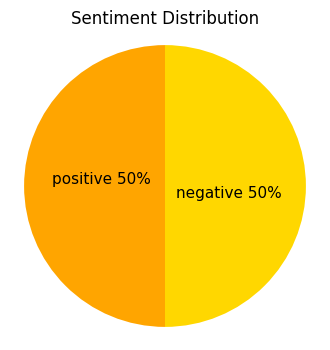

In [34]:
sentiment_counts = df_balanced["Sentiment"].value_counts()

colors = ["orange", "gold"]

plt.figure(figsize=(4,4))

plt.pie(
    sentiment_counts.values,
    startangle=90,
    colors=colors
)

# positionner les textes dans chaque moitié du cercle
plt.text(-0.45, 0.05, "positive 50%", ha='center', va='center', fontsize=11)
plt.text(0.45, -0.05, "negative 50%", ha='center', va='center', fontsize=11)

plt.title("Sentiment Distribution", fontsize=12)

plt.axis("equal")
plt.show()

In [35]:
df_balanced.to_csv("../data/processed/hotel_reviews_clean_balanced.csv", index=False)

print("✅ Balanced dataset saved successfully!")

✅ Balanced dataset saved successfully!


In [36]:
df = pd.read_csv("../data/processed/hotel_reviews_clean_balanced.csv")

print(df.shape)
df.head()

(35000, 2)


,Review,Sentiment
0,no windows in bed bathroom,negative
1,overall experience was superb breakfast was lo...,positive
2,friendly staff good location,positive
3,staff were so lovely and helpful very comfy be...,positive
4,fantastic location staff facilities,positive


In [37]:
df["label"] = df["Sentiment"].map({
    "negative": 0,
    "positive": 1
})

df = df[["Review", "label"]].dropna()

print(df["label"].value_counts())
df.head()

label
0    17500
1    17500
Name: count, dtype: int64


,Review,label
0,no windows in bed bathroom,0
1,overall experience was superb breakfast was lo...,1
2,friendly staff good location,1
3,staff were so lovely and helpful very comfy be...,1
4,fantastic location staff facilities,1


In [38]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train shape :", train_df.shape)
print("Validation shape :", val_df.shape)
print("Test shape :", test_df.shape)

print("\nTrain distribution:")
print(train_df["label"].value_counts(normalize=True))

print("\nValidation distribution:")
print(val_df["label"].value_counts(normalize=True))

print("\nTest distribution:")
print(test_df["label"].value_counts(normalize=True))

Train shape : (24500, 2)
Validation shape : (5250, 2)
Test shape : (5250, 2)

Train distribution:
label
1    0.5
0    0.5
Name: proportion, dtype: float64

Validation distribution:
label
0    0.5
1    0.5
Name: proportion, dtype: float64

Test distribution:
label
1    0.5
0    0.5
Name: proportion, dtype: float64


In [39]:
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

In [40]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize_function(example):
    return tokenizer(
        example["Review"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/24500 [00:00<?, ? examples/s]

Map:   0%|          | 0/5250 [00:00<?, ? examples/s]

Map:   0%|          | 0/5250 [00:00<?, ? examples/s]

In [41]:
train_dataset = train_dataset.remove_columns(["Review"])
val_dataset = val_dataset.remove_columns(["Review"])
test_dataset = test_dataset.remove_columns(["Review"])

train_dataset.set_format("torch")
val_dataset.set_format("torch")
test_dataset.set_format("torch")

In [42]:
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    precision = precision_metric.compute(predictions=predictions, references=labels, average="binary")
    recall = recall_metric.compute(predictions=predictions, references=labels, average="binary")
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="binary")

    return {
        "accuracy": accuracy["accuracy"],
        "precision": precision["precision"],
        "recall": recall["recall"],
        "f1": f1["f1"]
    }

In [43]:
import os
os.environ["HF_HUB_DISABLE_XET"] = "1"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "60"
os.environ["HF_HUB_ETAG_TIMEOUT"] = "60"

from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

print("Model downloaded successfully!")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model downloaded successfully!


In [44]:
training_args = TrainingArguments(
    output_dir="../models/distilbert_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    report_to="none"
)

In [45]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
)

In [46]:
trainer.train()
test_results = trainer.evaluate(test_dataset)
print(test_results)

C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.183600,0.144965,0.956952,0.969104,0.944000,0.956387
2,0.104900,0.160597,0.963238,0.969861,0.956190,0.962977
3,0.059000,0.199730,0.960952,0.967904,0.953524,0.960660


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 0.1957293301820755, 'eval_accuracy': 0.9567619047619048, 'eval_precision': 0.9665369649805448, 'eval_recall': 0.9462857142857143, 'eval_f1': 0.9563041385948027, 'eval_runtime': 414.0007, 'eval_samples_per_second': 12.681, 'eval_steps_per_second': 1.587, 'epoch': 3.0}


In [50]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

predictions_output = trainer.predict(test_dataset)

y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = np.array(test_df["label"])

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=["negative", "positive"]))

print("Confusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\nAccuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1-score :", round(f1, 4))

results = {
    "accuracy": acc,
    "precision": prec,
    "recall": rec,
    "f1": f1
}

pd.DataFrame([results]).to_csv("../outputs/test_metrics.csv", index=False)

print("\n✅ Metrics saved successfully!")

C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Classification Report:

              precision    recall  f1-score   support

    negative       0.95      0.97      0.96      2625
    positive       0.97      0.95      0.96      2625

    accuracy                           0.96      5250
   macro avg       0.96      0.96      0.96      5250
weighted avg       0.96      0.96      0.96      5250

Confusion Matrix:

[[2539   86]
 [ 141 2484]]

Accuracy : 0.9568
Precision: 0.9665
Recall   : 0.9463
F1-score : 0.9563

✅ Metrics saved successfully!


In [51]:
trainer.save_model("../models/distilbert_model")
tokenizer.save_pretrained("../models/distilbert_model")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [2]:
from transformers import pipeline
model_path = r"../models/distilbert_model"

classifier = pipeline(
    "sentiment-analysis",
    model=model_path,
    tokenizer=model_path
)

label_map = {0: "Negative", 1: "Positive"}

text = "good and bad"

result = classifier(text)[0]
label = label_map[int(result["label"][-1])]

print("Review:", text)
print("Sentiment:", label)
print("Confidence:", round(result["score"], 3))

Review: good and bad
Sentiment: Positive
Confidence: 0.831


In [2]:
import os
import re
import pandas as pd
from collections import Counter

# =========================
# Configuration
# =========================
REVIEWS_PATH = "../outputs/full_reviews_with_labels.csv"
OUTPUT_DIR = "../outputs/aspect_analysis"

TEXT_COLUMN = "Review"
SENTIMENT_COLUMN = "Sentiment"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# Load data
# =========================
df = pd.read_csv(REVIEWS_PATH)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

# =========================
# Keep only negative reviews
# =========================
df[SENTIMENT_COLUMN] = df[SENTIMENT_COLUMN].astype(str).str.lower().str.strip()
negative_df = df[df[SENTIMENT_COLUMN] == "negative"].copy().reset_index(drop=True)

print("Initial negative reviews:", negative_df.shape[0])

# =========================
# Cleaning functions
# =========================
def normalize_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

useless_patterns = [
    r"^nothing$",
    r"^nothing at all$",
    r"^no complaints$",
    r"^none$",
    r"^na$",
    r"^n a$",
    r"^nil$",
    r"^nothing to say$",
    r"^can t think of anything major$",
    r"^absolutely nothing$",
    r"^everything was perfect$",
    r"^nothing everything was perfect$",
    r"^all was excellent$",
    r"^the hotel was perfect$"
]

def is_useless_review(text):
    if len(text.split()) < 3:
        return True
    for pattern in useless_patterns:
        if re.fullmatch(pattern, text):
            return True
    return False

# =========================
# Clean negative reviews
# =========================
negative_df["clean_review"] = negative_df[TEXT_COLUMN].astype(str).apply(normalize_text)

negative_df = negative_df[
    ~negative_df["clean_review"].apply(is_useless_review)
].copy().reset_index(drop=True)

print("After cleaning:", negative_df.shape[0])

# =========================
# Define aspects
# =========================
ASPECTS = {
    "room": ["room", "bed", "bathroom", "shower"],
    "staff_service": ["staff", "service", "reception"],
    "breakfast_food": ["breakfast", "food", "coffee"],
    "wifi_internet": ["wifi", "internet", "connection"],
    "cleanliness": ["clean", "dirty", "smell"],
    "noise": ["noise", "loud", "sound"],
    "location": ["location", "distance", "metro"],
    "price_value": ["price", "expensive", "value"]
}

# =========================
# Extract aspects
# =========================
def extract_aspects(text):
    text = f" {text} "
    found = []

    for aspect, keywords in ASPECTS.items():
        for word in keywords:
            if f" {word} " in text:
                found.append(aspect)
                break

    return found

negative_df["aspects"] = negative_df["clean_review"].apply(extract_aspects)

negative_df = negative_df[
    negative_df["aspects"].map(len) > 0
].copy().reset_index(drop=True)

print("After aspect extraction:", negative_df.shape[0])

# =========================
# Count aspects
# =========================
all_aspects = []

for lst in negative_df["aspects"]:
    all_aspects.extend(lst)

aspect_counts = Counter(all_aspects)

aspect_counts_df = pd.DataFrame(
    aspect_counts.items(),
    columns=["aspect", "count"]
).sort_values(by="count", ascending=False).reset_index(drop=True)

print("\nAspect frequency:")
print(aspect_counts_df)

# =========================
# Save results
# =========================
negative_df.to_csv(
    os.path.join(OUTPUT_DIR, "negative_reviews_with_aspects.csv"),
    index=False
)

aspect_counts_df.to_csv(
    os.path.join(OUTPUT_DIR, "aspect_frequency.csv"),
    index=False
)

# =========================
# Explode aspects
# =========================
exploded_df = negative_df.explode("aspects").rename(columns={"aspects": "aspect"})
exploded_df.to_csv(
    os.path.join(OUTPUT_DIR, "negative_reviews_exploded_by_aspect.csv"),
    index=False
)

# =========================
# Show samples
# =========================
print("\nSample reviews by aspect:\n")

samples = []

for aspect in aspect_counts_df["aspect"]:
    print("=" * 70)
    print(f"Aspect: {aspect}")
    print("=" * 70)

    reviews = exploded_df[exploded_df["aspect"] == aspect][TEXT_COLUMN].head(5).tolist()

    for i, review in enumerate(reviews, 1):
        print(f"{i}. {review}")
        samples.append({
            "aspect": aspect,
            "sample_id": i,
            "review": review
        })

    print()

samples_df = pd.DataFrame(samples)

samples_df.to_csv(
    os.path.join(OUTPUT_DIR, "aspect_sample_reviews.csv"),
    index=False
)

# =========================
# Final summary
# =========================
print("\nFinal Summary:")
print("Final negative reviews:", len(negative_df))
print("Number of aspects:", len(aspect_counts_df))

Dataset shape: (35000, 3)
Columns: ['Review', 'Sentiment', 'label']
Initial negative reviews: 17500
After cleaning: 17155
After aspect extraction: 12132

Aspect frequency:
           aspect  count
0            room   7765
1  breakfast_food   3202
2   staff_service   2772
3     price_value   1498
4     cleanliness    863
5           noise    772
6   wifi_internet    740
7        location    627

Sample reviews by aspect:

Aspect: room
1. no windows in bed bathroom
2. the coffee machine and the coffee with the kettle in the room hard to make coffee even though all the facilities were there
3. the bed was not that really comfortable
4. halls and room smelt of paint due to the current refurbishment luckily i didn t spend a lot of time in the room breakfast is a very poor offering
5. the small size of the room

Aspect: breakfast_food
1. the breakfast lacked healthy options no porridge and no greens berries no omelette either when i asked for greens i got a plate full of rucola with pesto st

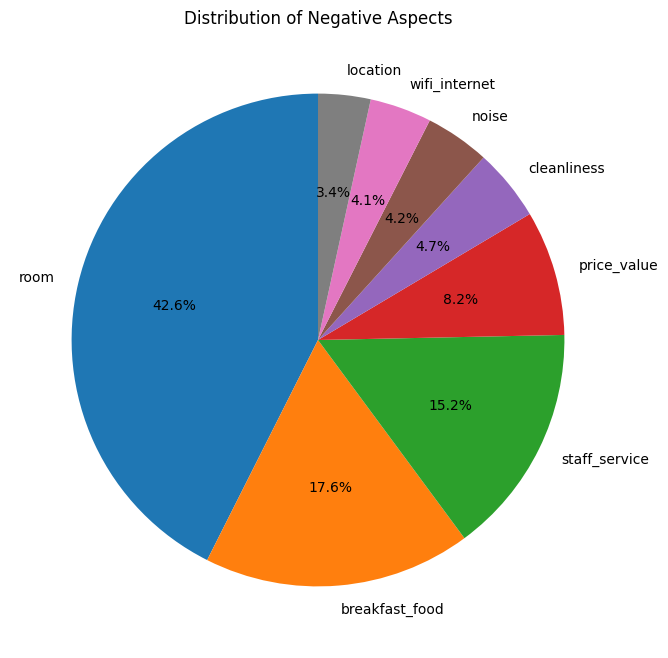

In [3]:
import matplotlib.pyplot as plt

aspect_counts_df["percentage"] = (
    aspect_counts_df["count"] / aspect_counts_df["count"].sum() * 100
).round(2)

plt.figure(figsize=(8, 8))
plt.pie(
    aspect_counts_df["count"],
    labels=aspect_counts_df["aspect"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Negative Aspects")
plt.show()

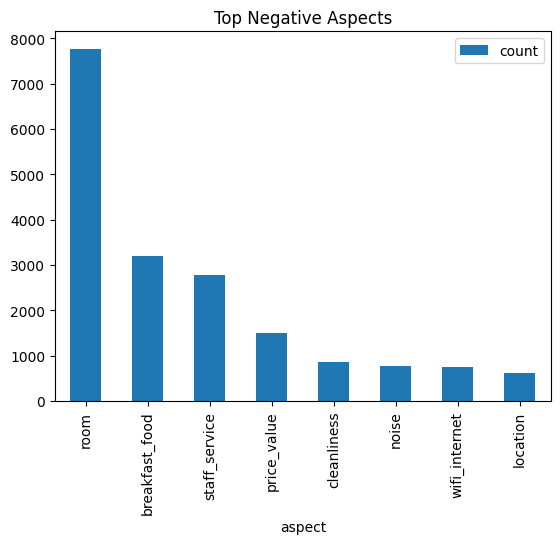

In [4]:
import matplotlib.pyplot as plt

aspect_counts_df.head(10).plot(
    x="aspect",
    y="count",
    kind="bar",
    title="Top Negative Aspects"
)
plt.show()

In [2]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

# =========================
# Configuration
# =========================
MODEL_NAME = "google/flan-t5-base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# Load model + tokenizer
# =========================
print("Loading FLAN-T5-base... (first time may take a few minutes)")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)

print("✅ Model loaded successfully on:", DEVICE)

Loading FLAN-T5-base... (first time may take a few minutes)
✅ Model loaded successfully on: cpu


In [3]:
import os
import pandas as pd
import json
import evaluate
from datasets import Dataset
from transformers import (
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)

# =========================
# Configuration
# =========================
DATA_PATH = r"../data\fine_tuning_recommendation_dataset\hotel_expert_datasets_cleaned.csv"
OUTPUT_DIR = "../models/flan_t5_recommendation_finetuned"

MAX_INPUT_LENGTH = 256
MAX_TARGET_LENGTH = 128
TRAIN_BATCH_SIZE = 4
EVAL_BATCH_SIZE = 4
LEARNING_RATE = 2e-5
NUM_EPOCHS = 3
WEIGHT_DECAY = 0.01
TEST_SIZE = 0.1
SEED = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)

# =========================
# Safety check
# =========================
try:
    tokenizer
    model
except NameError:
    raise ValueError("tokenizer/model are not loaded. Run the FLAN-T5-base loading cell first.")

# =========================
# Load dataset
# =========================
df = pd.read_csv(DATA_PATH)

required_columns = ["input", "target"]
missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[required_columns].dropna().reset_index(drop=True)

print("Dataset shape:", df.shape)
print(df.head())

# =========================
# Convert to Hugging Face dataset
# =========================
dataset = Dataset.from_pandas(df)
dataset = dataset.train_test_split(test_size=TEST_SIZE, seed=SEED)

train_dataset = dataset["train"]
val_dataset = dataset["test"]

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

# =========================
# Tokenization
# =========================
def preprocess_function(examples):
    model_inputs = tokenizer(
        examples["input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True
    )

    labels = tokenizer(
        text_target=examples["target"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_dataset = train_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=train_dataset.column_names
)

val_dataset = val_dataset.map(
    preprocess_function,
    batched=True,
    remove_columns=val_dataset.column_names
)

# =========================
# Data collator
# =========================
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

# =========================
# ROUGE metric
# =========================
rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # إذا predictions tuple
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    
    if len(predictions.shape) == 3:
        predictions = predictions.argmax(-1)

    
    predictions = [
        [int(p) if p >= 0 else tokenizer.pad_token_id for p in seq]
        for seq in predictions
    ]

    # decode predictions
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

     
    labels = [
        [l if l != -100 else tokenizer.pad_token_id for l in label]
        for label in labels
    ]

    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [label.strip() for label in decoded_labels]

    rouge_result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )

    return {
        "rouge1": round(rouge_result["rouge1"], 4),
        "rouge2": round(rouge_result["rouge2"], 4),
        "rougeL": round(rouge_result["rougeL"], 4),
        "rougeLsum": round(rouge_result["rougeLsum"], 4),
    }

# =========================
# Training arguments
# =========================
training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    weight_decay=WEIGHT_DECAY,
    save_total_limit=2,
    num_train_epochs=NUM_EPOCHS,
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,
    report_to="none",
    fp16=False
)

# =========================
# Trainer
# =========================
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# =========================
# Train
# =========================
print("\nStarting fine-tuning...")
train_result = trainer.train()

# =========================
# Final evaluation
# =========================
print("\nRunning final evaluation...")
eval_metrics = trainer.evaluate(max_length=MAX_TARGET_LENGTH)

print("\nEvaluation metrics:")
for k, v in eval_metrics.items():
    print(f"{k}: {v}")

# =========================
# Save model
# =========================
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

# =========================
# Save metrics
# =========================
all_metrics = {
    "train_metrics": train_result.metrics,
    "eval_metrics": eval_metrics
}

with open(os.path.join(OUTPUT_DIR, "metrics.json"), "w", encoding="utf-8") as f:
    json.dump(all_metrics, f, indent=2)

metrics_df = pd.DataFrame([{
    **{f"train_{k}": v for k, v in train_result.metrics.items()},
    **{f"eval_{k}": v for k, v in eval_metrics.items()}
}])
metrics_df.to_csv(os.path.join(OUTPUT_DIR, "metrics.csv"), index=False)

print("\nFine-tuning completed and model saved.")
print("Saved to:", OUTPUT_DIR)

Dataset shape: (3965, 2)
                                               input  \
0  Generate a professional hotel recommendation f...   
1  Write a hotel issue summary and a professional...   
2  Analyze this hotel complaint and provide an is...   
3  Generate a professional hotel recommendation f...   
4  Write a hotel issue summary and a professional...   

                                              target  
0  Issue summary: Guests reported significant dis...  
1  Issue summary: Guests with reduced mobility re...  
2  Issue summary: Guests reported inconsistencies...  
3  Issue summary: Guests expressed dissatisfactio...  
4  Issue summary: Guests raised concerns about th...  
Train size: 3568
Validation size: 397


Map:   0%|          | 0/3568 [00:00<?, ? examples/s]

Map:   0%|          | 0/397 [00:00<?, ? examples/s]


Starting fine-tuning...


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,2.065500,1.812256,0.393000,0.146200,0.347200,0.347100
2,1.926400,1.702812,0.400800,0.146800,0.346200,0.346400
3,1.778100,1.675395,0.405700,0.151800,0.351300,0.351300


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].



Running final evaluation...


C:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Evaluation metrics:
eval_loss: 1.6753950119018555
eval_rouge1: 0.4057
eval_rouge2: 0.1518
eval_rougeL: 0.3513
eval_rougeLsum: 0.3513
eval_runtime: 377.7675
eval_samples_per_second: 1.051
eval_steps_per_second: 0.265
epoch: 3.0

Fine-tuning completed and model saved.
Saved to: ../models/flan_t5_recommendation_finetuned


In [9]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

# =========================
# Load fine-tuned model
# =========================
MODEL_PATH = "../models/flan_t5_recommendation_finetuned"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_PATH).to(DEVICE)

model.eval()

print("Model loaded on:", DEVICE)

# =========================
# Test function
# =========================
def generate_recommendation(aspect, complaint):
    input_text = (
        f"Generate a professional hotel recommendation from this complaint. "
        f"Aspect: {aspect}. Complaint: {complaint}"
    )

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to(DEVICE)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            num_beams=5,
            no_repeat_ngram_size=3,
            repetition_penalty=1.2,
            early_stopping=True
        )

    result = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return result

test_examples = [
    ("room", "the room was ogly"),
    ("wifi_internet", "the wifi was slow and disconnected many times"),
    ("breakfast_food", "food is verry expensive and is high pricing"),
    ("staff_service", "the reception staff were not helpful and check in was slow"),
    ("cleanliness", "the bathroom was dirty and the towels did not smell fresh"),
]

for aspect, complaint in test_examples:
    print("=" * 80)
    print("Aspect:", aspect)
    print("Complaint:", complaint)
    print("Output:")
    print(generate_recommendation(aspect, complaint))
    print()

Model loaded on: cpu
Aspect: room
Complaint: the room was ogly
Output:
Issue summary: Guests reported dissatisfaction with room condition and overall comfort. Recommendation: Improve room comfort by improving room quality and cleaning standards.

Aspect: wifi_internet
Complaint: the wifi was slow and disconnected many times
Output:
Issue summary: Guests reported slow Wi-Fi connectivity and frequent disconnections, affecting comfort. Recommendation: Improve network reliability and ensure reliable connectivity throughout the guest experience.

Aspect: breakfast_food
Complaint: food is verry expensive and is high pricing
Output:
Issue summary: Guests expressed dissatisfaction with breakfast pricing due to high pricing and poor service quality. Recommendation: Improve breakfast quality by aligning pricing with quality and service standards.

Aspect: staff_service
Complaint: the reception staff were not helpful and check in was slow
Output:
Issue summary: Guests reported dissatisfaction wit